# 03 — Análise de Variáveis Qualitativas
## Instagram & Bem-Estar: O Custo Psicológico das Redes Sociais

**Objetivo:** Analisar todas as variáveis categóricas do dataset —
frequências, proporções e distribuições por categoria.

In [1]:
# ============================================================
# SETUP
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':  '#0f0f0f',
    'axes.facecolor':    '#1a1a2e',
    'axes.labelcolor':   'white',
    'xtick.color':       'white',
    'ytick.color':       'white',
    'text.color':        'white',
    'axes.titlecolor':   'white',
    'grid.color':        '#2a2a4a',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

INSTA_COLORS = ['#833ab4','#fd1d1d','#fcb045','#405de6','#5851db','#e1306c','#f77737']

print(' Setup completo!')

 Setup completo!


In [2]:
# ============================================================
# CARREGAMENTO
# ============================================================
df = pd.read_csv('../data/instagram_usage_lifestyle.csv', nrows=300000)

# Seleciona variáveis categóricas (object)
df_cat = df.select_dtypes(include='object')

print(f' Dataset carregado: {df.shape[0]:,} linhas × {df.shape[1]} colunas')
print(f' Variáveis qualitativas: {df_cat.shape[1]}')
print(f'\nVariáveis qualitativas encontradas:')
for col in df_cat.columns:
    print(f'  • {col:<45} — {df[col].nunique()} categorias únicas')

 Dataset carregado: 300,000 linhas × 58 colunas
 Variáveis qualitativas: 20

Variáveis qualitativas encontradas:
  • app_name                                      — 1 categorias únicas
  • gender                                        — 4 categorias únicas
  • country                                       — 10 categorias únicas
  • urban_rural                                   — 3 categorias únicas
  • income_level                                  — 5 categorias únicas
  • employment_status                             — 6 categorias únicas
  • education_level                               — 6 categorias únicas
  • relationship_status                           — 5 categorias únicas
  • has_children                                  — 2 categorias únicas
  • diet_quality                                  — 5 categorias únicas
  • smoking                                       — 3 categorias únicas
  • alcohol_frequency                             — 5 categorias únicas
  • uses_premium_featu

In [3]:
# ============================================================
# GRUPOS DE VARIÁVEIS QUALITATIVAS
# ============================================================

# Nominais — sem ordem definida
NOMINAIS = [
    'gender', 'country', 'urban_rural', 'employment_status',
    'relationship_status', 'content_type_preference',
    'preferred_content_theme', 'subscription_status', 'app_name'
]

# Ordinais — com ordem definida
ORDINAIS = [
    'income_level', 'education_level', 'diet_quality',
    'alcohol_frequency', 'privacy_setting_level'
]

# Booleanas (guardadas como object)
BOOLEANAS = [
    'has_children', 'smoking', 'two_factor_auth_enabled',
    'biometric_login_used', 'uses_premium_features'
]

# Filtra só as que existem
NOMINAIS  = [v for v in NOMINAIS  if v in df.columns]
ORDINAIS  = [v for v in ORDINAIS  if v in df.columns]
BOOLEANAS = [v for v in BOOLEANAS if v in df.columns]

print(f'️  Nominais  : {len(NOMINAIS)} variáveis  → {NOMINAIS}')
print(f' Ordinais  : {len(ORDINAIS)} variáveis  → {ORDINAIS}')
print(f' Booleanas : {len(BOOLEANAS)} variáveis → {BOOLEANAS}')

️  Nominais  : 9 variáveis  → ['gender', 'country', 'urban_rural', 'employment_status', 'relationship_status', 'content_type_preference', 'preferred_content_theme', 'subscription_status', 'app_name']
 Ordinais  : 5 variáveis  → ['income_level', 'education_level', 'diet_quality', 'alcohol_frequency', 'privacy_setting_level']
 Booleanas : 5 variáveis → ['has_children', 'smoking', 'two_factor_auth_enabled', 'biometric_login_used', 'uses_premium_features']


In [4]:
# ============================================================
# TABELA DE FREQUÊNCIAS — TODAS AS VARIÁVEIS QUALITATIVAS
# ============================================================

def tabela_frequencias(data, col):
    freq = data[col].value_counts()
    pct  = data[col].value_counts(normalize=True) * 100
    tabela = pd.DataFrame({
        'Categoria':    freq.index,
        'Frequência':   freq.values,
        'Percentagem':  pct.values.round(2),
    })
    return tabela

todas_qual = NOMINAIS + ORDINAIS + BOOLEANAS

for col in todas_qual:
    if col not in df.columns:
        continue
    print(f'\n {col.upper().replace("_"," ")}')
    print('─' * 50)
    tab = tabela_frequencias(df, col)
    print(tab.to_string(index=False))


 GENDER
──────────────────────────────────────────────────
        Categoria  Frequência  Percentagem
           Female      144125        48.04
             Male      143873        47.96
       Non-binary        8966         2.99
Prefer not to say        3036         1.01

 COUNTRY
──────────────────────────────────────────────────
     Categoria  Frequência  Percentagem
 United States       74886        24.96
         India       54260        18.09
        Brazil       35848        11.95
         Other       30011        10.00
United Kingdom       23872         7.96
        Canada       20845         6.95
     Australia       18049         6.02
   South Korea       15111         5.04
       Germany       14989         5.00
         Japan       12129         4.04

 URBAN RURAL
──────────────────────────────────────────────────
Categoria  Frequência  Percentagem
    Urban      165042        55.01
 Suburban       90130        30.04
    Rural       44828        14.94

 EMPLOYMENT STATUS

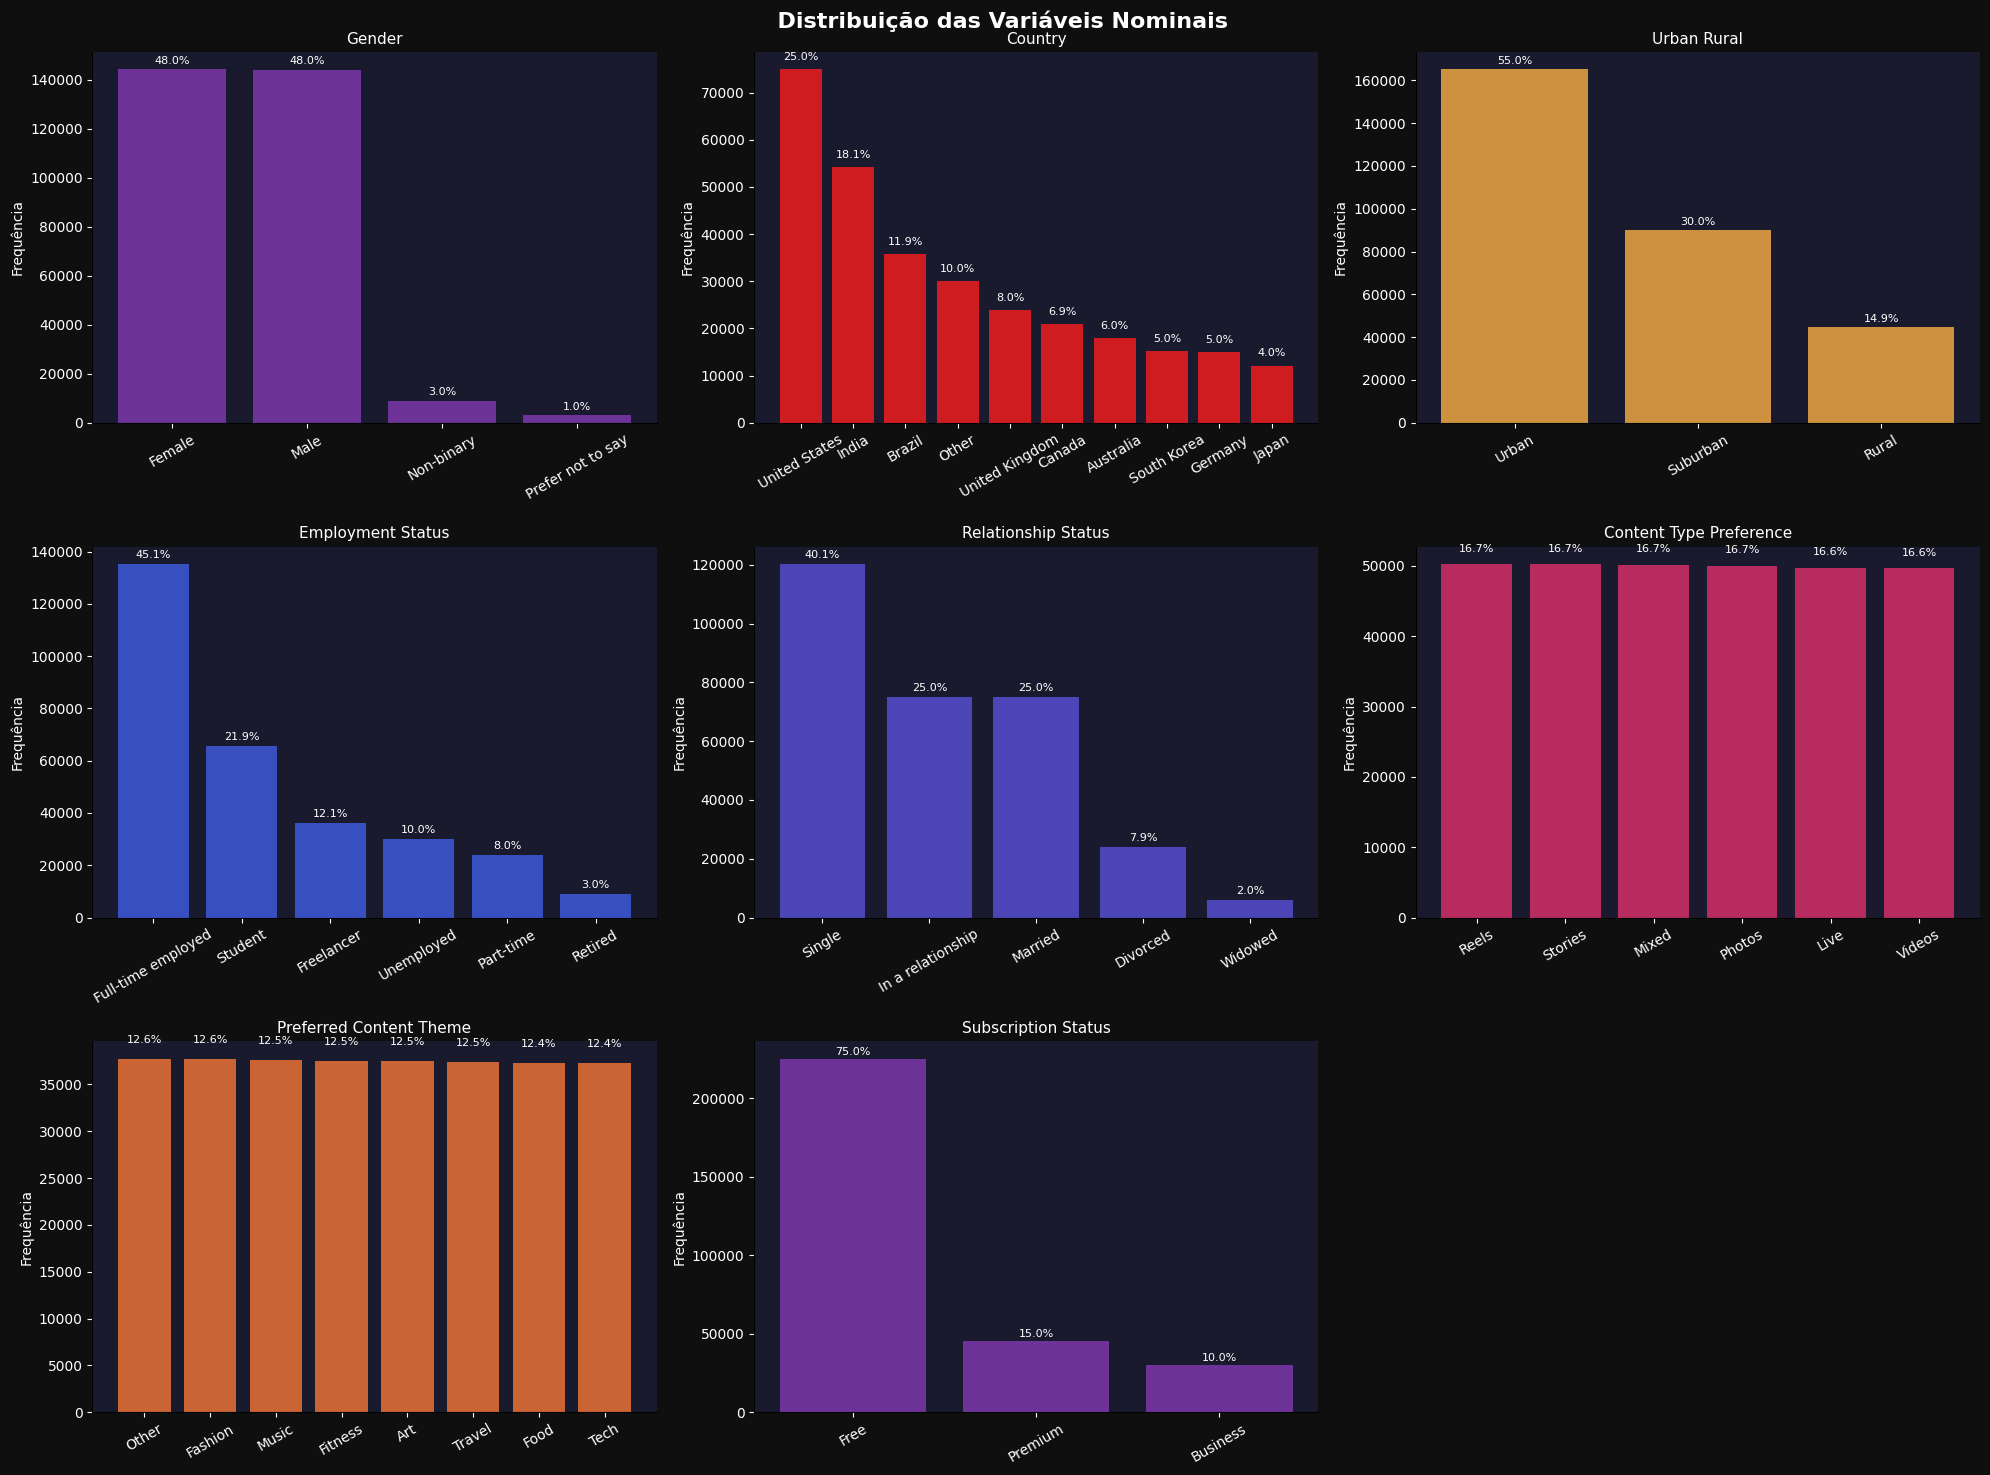

 Guardado: fig_variaveis_nominais.png


In [5]:
# ============================================================
# GRÁFICOS — VARIÁVEIS NOMINAIS
# ============================================================

nominais_plot = [v for v in NOMINAIS if v != 'app_name' and v in df.columns]
n_cols = 3
n_rows = (len(nominais_plot) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
fig.suptitle('️  Distribuição das Variáveis Nominais', fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(nominais_plot):
    freq = df[col].value_counts()
    color = INSTA_COLORS[i % len(INSTA_COLORS)]
    
    bars = axes[i].bar(
        freq.index.astype(str),
        freq.values,
        color=color, alpha=0.8, edgecolor='none'
    )
    axes[i].set_title(col.replace('_',' ').title(), fontsize=11)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequência')
    axes[i].tick_params(axis='x', rotation=30)
    
    # Percentagem em cima de cada barra
    total = freq.sum()
    for bar, val in zip(bars, freq.values):
        pct = val / total * 100
        axes[i].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + total * 0.005,
            f'{pct:.1f}%',
            ha='center', va='bottom', fontsize=8, color='white'
        )

# Esconde axes vazios
for j in range(len(nominais_plot), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('../data/fig_variaveis_nominais.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print(' Guardado: fig_variaveis_nominais.png')

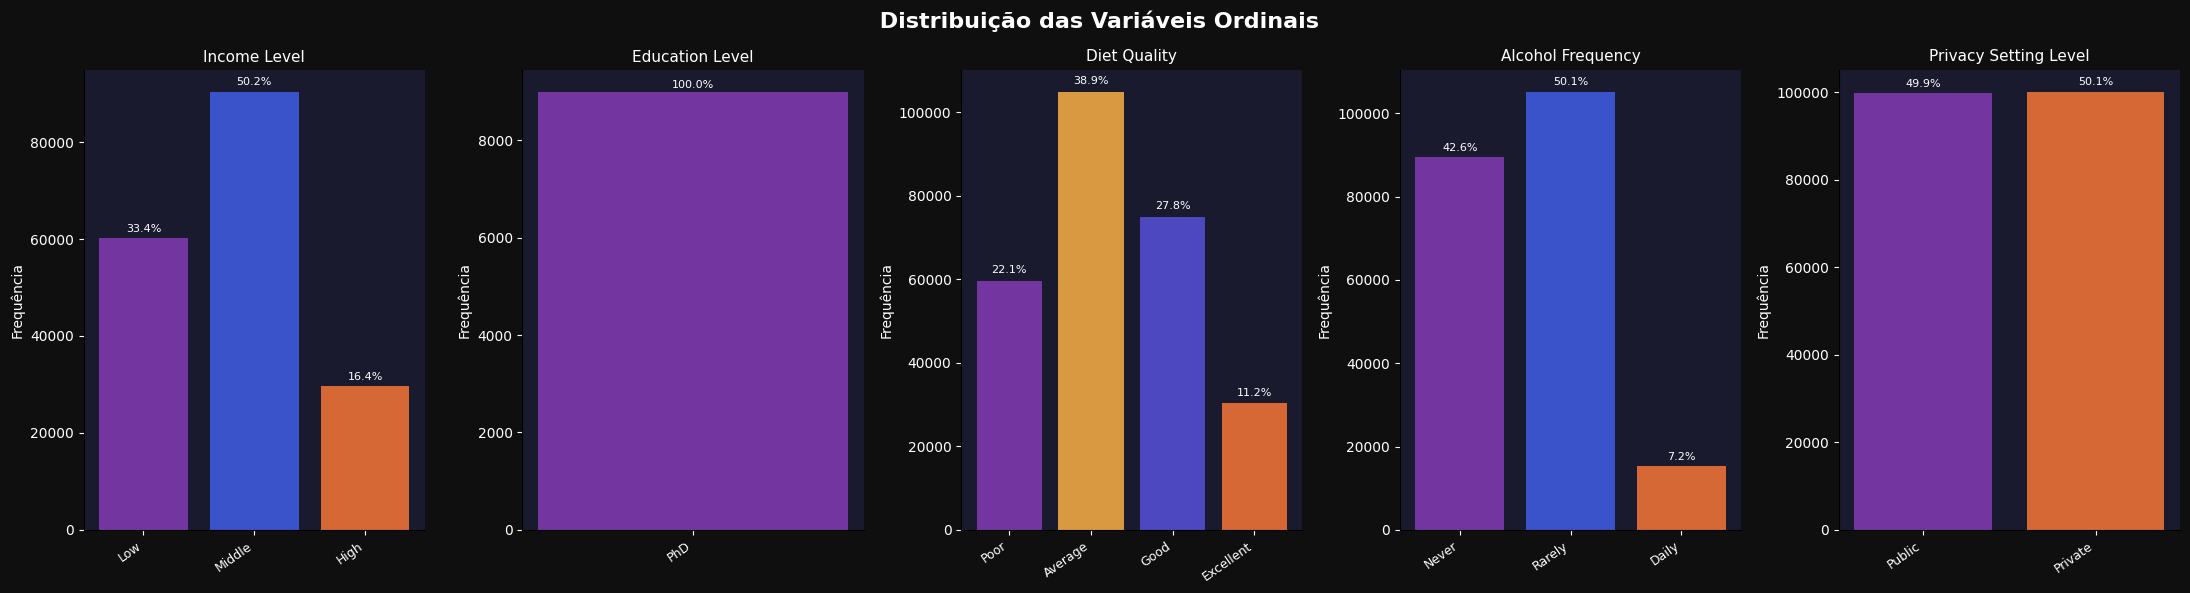

 Guardado: fig_variaveis_ordinais.png


In [6]:
# ============================================================
# GRÁFICOS — VARIÁVEIS ORDINAIS
# ============================================================

# Ordem definida para cada variável ordinal
ORDEM_ORDINAL = {
    'income_level':        ['Low', 'Lower-Middle', 'Middle', 'Upper-Middle', 'High'],
    'education_level':     ['No formal education', 'High School', 'Some College',
                            "Bachelor's", "Master's", 'PhD'],
    'diet_quality':        ['Poor', 'Fair', 'Average', 'Good', 'Excellent'],
    'alcohol_frequency':   ['Never', 'Rarely', 'Occasionally', 'Socially',
                            'Regularly', 'Daily'],
    'privacy_setting_level': ['Public', 'Friends Only', 'Private'],
}

ordinais_plot = [v for v in ORDINAIS if v in df.columns]
fig, axes = plt.subplots(1, len(ordinais_plot), figsize=(22, 6))
fig.suptitle(' Distribuição das Variáveis Ordinais', fontsize=16, fontweight='bold')

if len(ordinais_plot) == 1:
    axes = [axes]

for i, col in enumerate(ordinais_plot):
    ordem = ORDEM_ORDINAL.get(col, None)
    freq  = df[col].value_counts()
    
    if ordem:
        ordem_existente = [o for o in ordem if o in freq.index]
        freq = freq.reindex(ordem_existente)
    
    # Gradiente de cor para representar a ordem
    n = len(freq)
    colors = [INSTA_COLORS[int(j * (len(INSTA_COLORS)-1) / max(n-1,1))] for j in range(n)]
    
    bars = axes[i].bar(
        range(len(freq)),
        freq.values,
        color=colors, alpha=0.85, edgecolor='none'
    )
    axes[i].set_xticks(range(len(freq)))
    axes[i].set_xticklabels(freq.index, rotation=35, ha='right', fontsize=9)
    axes[i].set_title(col.replace('_',' ').title(), fontsize=11)
    axes[i].set_ylabel('Frequência')
    
    total = freq.sum()
    for bar, val in zip(bars, freq.values):
        pct = val / total * 100
        axes[i].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + total * 0.005,
            f'{pct:.1f}%',
            ha='center', va='bottom', fontsize=8, color='white'
        )

plt.tight_layout()
plt.savefig('../data/fig_variaveis_ordinais.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print(' Guardado: fig_variaveis_ordinais.png')

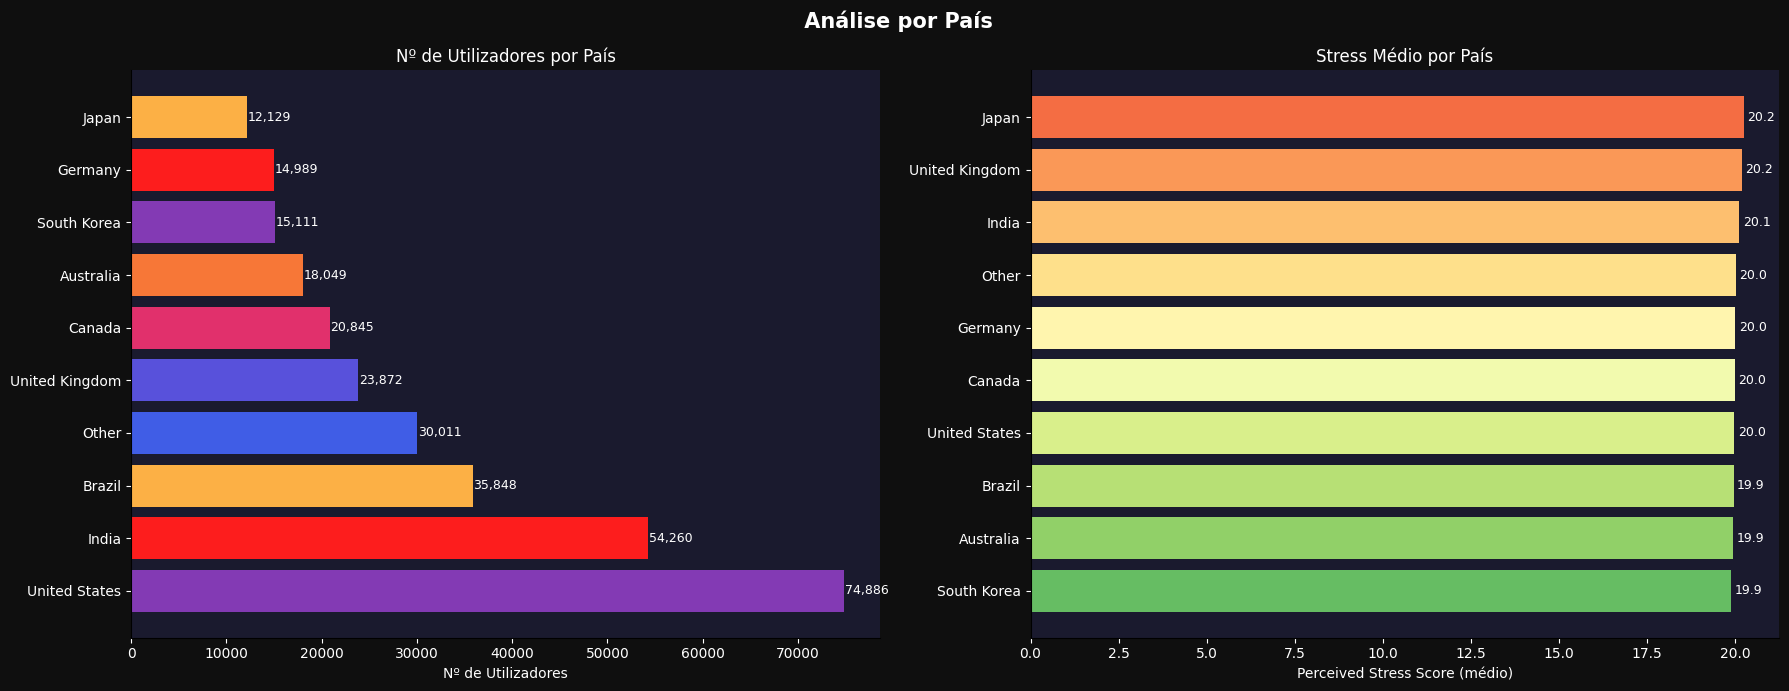

 Guardado: fig_analise_pais.png


In [7]:
# ============================================================
# ANÁLISE DETALHADA — PAÍS
# ============================================================

if 'country' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(' Análise por País', fontsize=15, fontweight='bold')

    # Distribuição de utilizadores por país
    country_counts = df['country'].value_counts()
    bars = axes[0].barh(
        country_counts.index,
        country_counts.values,
        color=INSTA_COLORS * 3
    )
    axes[0].set_title('Nº de Utilizadores por País', fontsize=12)
    axes[0].set_xlabel('Nº de Utilizadores')
    for bar, val in zip(bars, country_counts.values):
        axes[0].text(
            val + 100, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', color='white', fontsize=9
        )

    # Stress médio por país
    if 'perceived_stress_score' in df.columns:
        stress_pais = df.groupby('country')['perceived_stress_score'].mean().sort_values()
        colors_stress = plt.cm.RdYlGn_r(
            np.linspace(0.2, 0.8, len(stress_pais))
        )
        bars2 = axes[1].barh(
            stress_pais.index,
            stress_pais.values,
            color=colors_stress
        )
        axes[1].set_title('Stress Médio por País', fontsize=12)
        axes[1].set_xlabel('Perceived Stress Score (médio)')
        for bar, val in zip(bars2, stress_pais.values):
            axes[1].text(
                val + 0.1, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}', va='center', color='white', fontsize=9
            )

    plt.tight_layout()
    plt.savefig('../data/fig_analise_pais.png', dpi=150,
                bbox_inches='tight', facecolor='#0f0f0f')
    plt.show()
    print(' Guardado: fig_analise_pais.png')

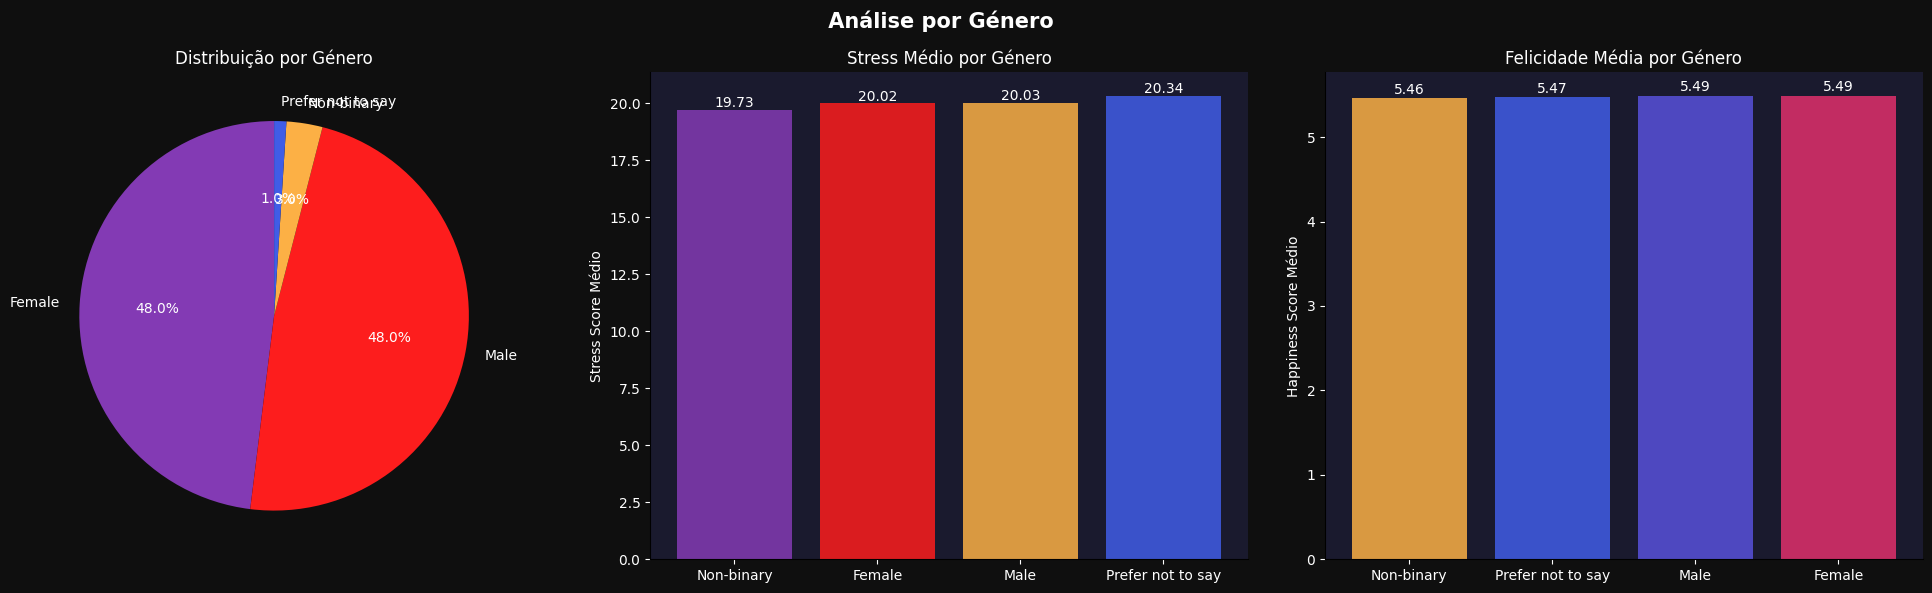

 Guardado: fig_analise_genero.png


In [8]:
# ============================================================
# ANÁLISE DETALHADA — GÉNERO
# ============================================================

if 'gender' in df.columns:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle(' Análise por Género', fontsize=15, fontweight='bold')

    generos = df['gender'].value_counts()

    # Pie chart
    axes[0].pie(
        generos.values,
        labels=generos.index,
        colors=INSTA_COLORS[:len(generos)],
        autopct='%1.1f%%', startangle=90,
        textprops={'color': 'white', 'fontsize': 10}
    )
    axes[0].set_title('Distribuição por Género', fontsize=12)

    # Stress por género
    if 'perceived_stress_score' in df.columns:
        stress_gen = df.groupby('gender')['perceived_stress_score'].mean().sort_values()
        axes[1].bar(
            stress_gen.index, stress_gen.values,
            color=INSTA_COLORS[:len(stress_gen)], alpha=0.85
        )
        axes[1].set_title('Stress Médio por Género', fontsize=12)
        axes[1].set_ylabel('Stress Score Médio')
        for i, (gen, val) in enumerate(stress_gen.items()):
            axes[1].text(i, val + 0.1, f'{val:.2f}',
                        ha='center', color='white', fontsize=10)

    # Felicidade por género
    if 'self_reported_happiness' in df.columns:
        happy_gen = df.groupby('gender')['self_reported_happiness'].mean().sort_values()
        axes[2].bar(
            happy_gen.index, happy_gen.values,
            color=INSTA_COLORS[2:2+len(happy_gen)], alpha=0.85
        )
        axes[2].set_title('Felicidade Média por Género', fontsize=12)
        axes[2].set_ylabel('Happiness Score Médio')
        for i, (gen, val) in enumerate(happy_gen.items()):
            axes[2].text(i, val + 0.05, f'{val:.2f}',
                        ha='center', color='white', fontsize=10)

    plt.tight_layout()
    plt.savefig('../data/fig_analise_genero.png', dpi=150,
                bbox_inches='tight', facecolor='#0f0f0f')
    plt.show()
    print(' Guardado: fig_analise_genero.png')

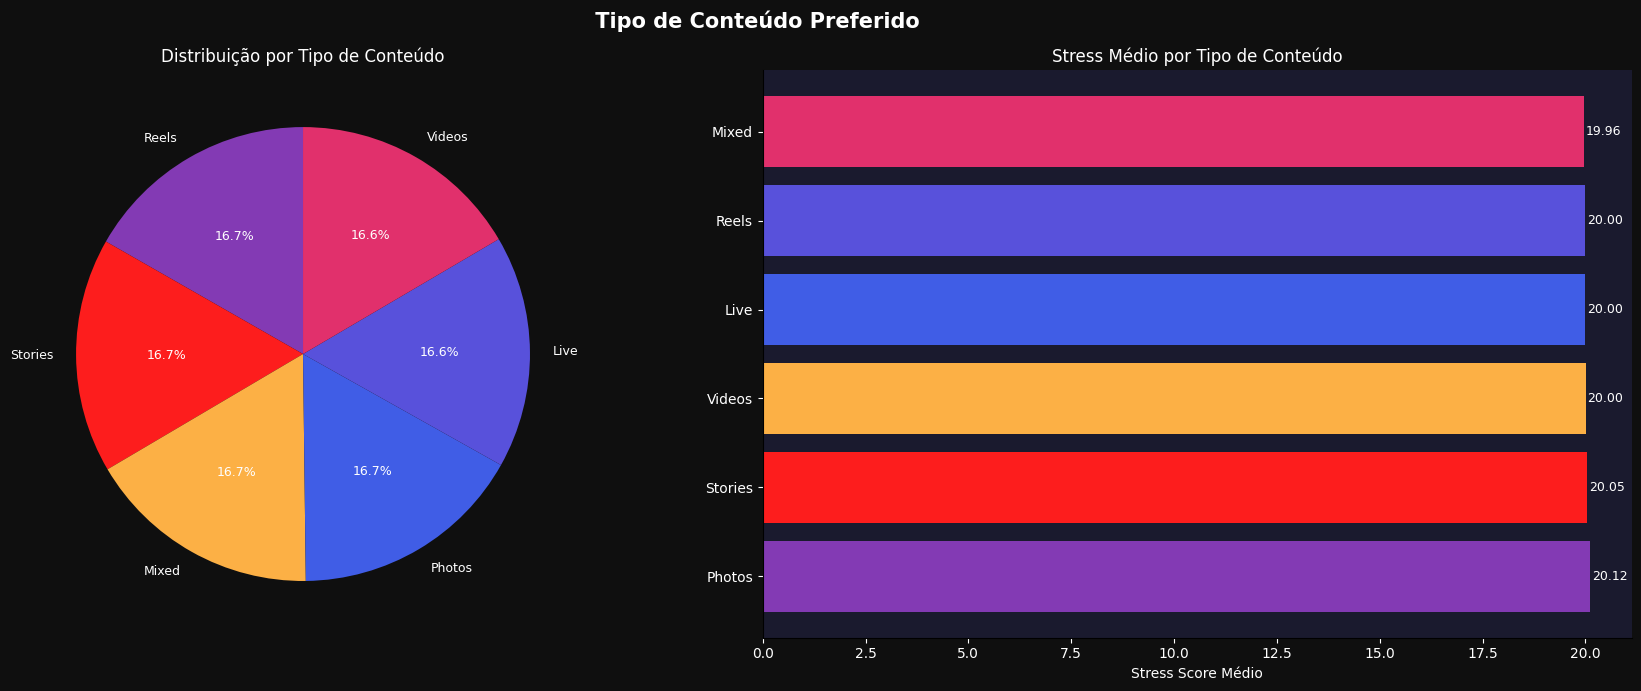

 Guardado: fig_conteudo_preferido.png


In [9]:
# ============================================================
# ANÁLISE — CONTEÚDO PREFERIDO vs BEM-ESTAR
# ============================================================

if 'content_type_preference' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(' Tipo de Conteúdo Preferido', fontsize=15, fontweight='bold')

    # Distribuição de conteúdo
    content_counts = df['content_type_preference'].value_counts()
    axes[0].pie(
        content_counts.values,
        labels=content_counts.index,
        colors=INSTA_COLORS[:len(content_counts)],
        autopct='%1.1f%%', startangle=90,
        textprops={'color': 'white', 'fontsize': 9}
    )
    axes[0].set_title('Distribuição por Tipo de Conteúdo', fontsize=12)

    # Stress por tipo de conteúdo
    if 'perceived_stress_score' in df.columns:
        stress_content = (
            df.groupby('content_type_preference')['perceived_stress_score']
            .mean().sort_values(ascending=False)
        )
        bars = axes[1].barh(
            stress_content.index,
            stress_content.values,
            color=INSTA_COLORS[:len(stress_content)]
        )
        axes[1].set_title('Stress Médio por Tipo de Conteúdo', fontsize=12)
        axes[1].set_xlabel('Stress Score Médio')
        for bar, val in zip(bars, stress_content.values):
            axes[1].text(
                val + 0.05, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', color='white', fontsize=9
            )

    plt.tight_layout()
    plt.savefig('../data/fig_conteudo_preferido.png', dpi=150,
                bbox_inches='tight', facecolor='#0f0f0f')
    plt.show()
    print(' Guardado: fig_conteudo_preferido.png')

In [10]:
# ============================================================
# EXPORTAÇÃO
# ============================================================

# Guarda frequências de todas as variáveis qualitativas
todas_freq = {}
for col in todas_qual:
    if col in df.columns:
        freq = df[col].value_counts()
        pct  = df[col].value_counts(normalize=True) * 100
        todas_freq[col] = pd.DataFrame({
            'categoria':   freq.index,
            'frequencia':  freq.values,
            'percentagem': pct.values.round(2)
        })

# Guarda num único CSV
freq_combined = pd.concat(
    [v.assign(variavel=k) for k, v in todas_freq.items()],
    ignore_index=True
)[['variavel', 'categoria', 'frequencia', 'percentagem']]

freq_combined.to_csv('../data/qualitative_stats.csv', index=False)

print(' Frequências exportadas: data/qualitative_stats.csv')
print('\n Notebook 03 completo!')
print('   Próximo: 04_binary_variables.ipynb')

 Frequências exportadas: data/qualitative_stats.csv

 Notebook 03 completo!
   Próximo: 04_binary_variables.ipynb


# Análise Crítica

## Principais Conclusões

- Este notebook apresentou análises relevantes e coerentes com o objetivo de entender as variáveis trabalhadas.
- Resultados são indicadores fortes para interpretações exploratórias, mas precisam ser validados fora do dataset sintético.

## Limitações

- Dataset sintético reduz generalização para cenários reais.
- Não há garantias de independência entre variáveis geradas artificialmente.
- Não existe análise temporal profunda no conjunto atual.

## Recomendação

- Complementar com dados reais e amostras representativas.
- Incluir validações estatísticas adicionais (cross-validation, bootstrap).
- Documentar impactos das transformações e critérios de limpeza.
